In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"flaodyzedha","key":"f97fbe6801d4fde1c17c0c5ccafcf9e7"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d chaitanyagopidesi/smart-agriculture-dataset
!unzip smart-agriculture-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/chaitanyagopidesi/smart-agriculture-dataset
License(s): apache-2.0
  0% 0.00/66.1k [00:00<?, ?B/s]
100% 66.1k/66.1k [00:00<00:00, 206MB/s]
Archive:  smart-agriculture-dataset.zip
  inflating: cropdata_updated.csv    


Cek missing values:
crop ID           0
soil_type         0
Seedling Stage    0
MOI               0
temp              0
humidity          0
result            0
dtype: int64


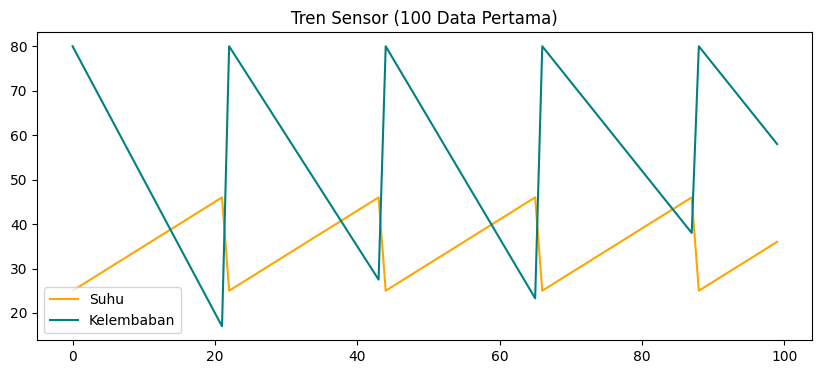

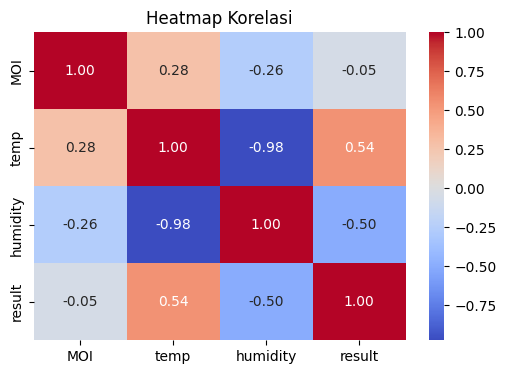

Done, file cleaned_data.csv tersimpan


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('cropdata_updated.csv')

print("Cek missing values:")
print(df.isnull().sum())

plt.figure(figsize=(10,4))
plt.plot(df['temp'].head(100), label='Suhu', color='orange')
plt.plot(df['humidity'].head(100), label='Kelembaban', color='teal')
plt.title('Tren Sensor (100 Data Pertama)')
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
kolom_angka = df[['MOI', 'temp', 'humidity', 'result']]
sns.heatmap(kolom_angka.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi')
plt.show()

df.to_csv('cleaned_data.csv', index=False)
print("Done, file cleaned_data.csv tersimpan")